# Notebook 12: Data Center Signature — Stage A trend (2019–2025)

**One Sensor, One Year — Edition 2: US Grid**

Stage B (notebook 11) confirmed the cross-sectional signal: in 2025 the three hyperscaler-heavy BAs (PJM, ERCO, MISO) sit above the control on all three demand-shape metrics. This notebook adds the time axis. With the per-BA panel from notebook 01c we can ask the harder question:

> **Has the hyperscaler-vs-control gap been widening as data-center capex ramped from 2019 to 2025?**

If yes, the data-center anchor is not just regional — it's a *trend* with directionality, and that's the Ed2 essay's spine.

**Inputs:** `../data/processed/ba_2019_2025_hourly.parquet` (combined panel, 10 BAs × 7 years × hourly × fuel)  
**Method:** Re-run the same three signature functions from notebook 11 verbatim, applied per-(BA, year). Plot the hyper-mean − ctrl-mean gap over time, signal by signal.

**Sanity check:** The 2025 numbers from this notebook must match notebook 11 exactly — overnight gap +1.78 pp, weekend gap +0.65 pp, P90 floor gap +11.56 pp.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

PROCESSED = Path('../data/processed')
panel_raw = pd.read_parquet(PROCESSED / 'ba_2019_2025_hourly.parquet')

print(f'Loaded {len(panel_raw):,} rows  '
      f'({panel_raw["respondent"].nunique()} BAs × {panel_raw["year"].nunique()} years × '
      f'{panel_raw["fueltype"].nunique()} fuels)')
print(f'Years:        {sorted(panel_raw["year"].unique())}')
print(f'BAs:          {sorted(panel_raw["respondent"].unique())}')

Loaded 4,795,910 rows  (10 BAs × 7 years × 16 fuels)
Years:        [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
BAs:          ['BPAT', 'CISO', 'ERCO', 'ISNE', 'MISO', 'NYIS', 'PJM', 'SOCO', 'SWPP', 'TVA']


## Groups and signal functions (verbatim from notebook 11)

Reusing the exact functions so any 2025-year result must match the Stage-B prototype byte-for-byte.

In [2]:
HYPERSCALER = ['PJM', 'ERCO', 'MISO']
CONTROL     = ['BPAT', 'CISO', 'ISNE', 'NYIS', 'SOCO', 'SWPP', 'TVA']
BA_ORDER    = HYPERSCALER + CONTROL

HYPER_COLOR = '#C0392B'
CTRL_COLOR  = '#2C3E50'
GAP_COLOR   = '#E67E22'

BA_LABELS = {
    'PJM':  'PJM (VA+)', 'ERCO': 'ERCOT (TX)', 'MISO': 'MISO (Midwest)',
    'BPAT': 'BPA (NW)',  'CISO': 'CAISO (CA)', 'ISNE': 'ISO-NE',
    'NYIS': 'NYISO',     'SOCO': 'Southern Co.','SWPP': 'SPP', 'TVA':  'TVA',
}

def overnight_share(series):
    s = series.dropna()
    daily = s.groupby(s.index.date)
    peak  = daily.max()
    night = s[s.index.hour.isin([2, 3, 4, 5])].groupby(lambda t: t.date()).mean()
    aligned = pd.concat([peak, night], axis=1, keys=['peak', 'night']).dropna()
    return (aligned['night'] / aligned['peak']).mean()

def weekend_ratio(series):
    s = series.dropna()
    is_weekend = s.index.dayofweek.isin([5, 6])
    return s[is_weekend].mean() / s[~is_weekend].mean()

def ldc_floor_p90(series):
    s = series.dropna().values
    if len(s) == 0:
        return np.nan
    sorted_desc = np.sort(s)[::-1] / s.max()
    return sorted_desc[int(len(sorted_desc) * 0.9)]

## Per-(BA, year) signal panel

For each year, sum across fuels per (BA, hour) to get a demand proxy, then apply the three signal functions per BA.

In [3]:
years = sorted(panel_raw['year'].unique())
records = []
for year in years:
    sub = panel_raw[panel_raw['year'] == year]
    gen = (sub.groupby(['respondent', 'period'])['value_mwh']
              .sum()
              .unstack('respondent')
              .sort_index())
    gen.index = pd.to_datetime(gen.index)

    for ba in BA_ORDER:
        if ba not in gen.columns:
            continue
        s = gen[ba]
        records.append({
            'year': year,
            'respondent': ba,
            'group': 'hyper' if ba in HYPERSCALER else 'ctrl',
            'overnight_share': overnight_share(s),
            'weekend_ratio':   weekend_ratio(s),
            'ldc_floor_p90':   ldc_floor_p90(s),
        })

panel = pd.DataFrame(records)
print(f'Panel: {len(panel)} rows  ({panel["respondent"].nunique()} BAs × {panel["year"].nunique()} years)')
panel.head(10).round(3)

Panel: 70 rows  (10 BAs × 7 years)


,year,respondent,group,overnight_share,weekend_ratio,ldc_floor_p90
0,2019,PJM,hyper,0.832,0.929,0.488
1,2019,ERCO,hyper,0.877,0.950,0.453
2,2019,MISO,hyper,0.887,0.920,0.503
3,2019,BPAT,ctrl,0.946,0.945,0.483
4,2019,CISO,ctrl,0.835,0.912,0.326
5,2019,ISNE,ctrl,0.768,0.910,0.395
6,2019,NYIS,ctrl,0.828,0.931,0.425
7,2019,SOCO,ctrl,0.833,0.924,0.471
8,2019,SWPP,ctrl,0.908,0.949,0.489
9,2019,TVA,ctrl,0.836,0.929,0.230


## Sanity check — 2025 numbers must match notebook 11

If aggregation drift broke anything, the 2025 cross-section here will diverge from NB 11. Asserting tight tolerance so a regression fails loud.

In [4]:
p25 = panel[panel['year'] == 2025]
g25 = p25.groupby('group')[['overnight_share', 'weekend_ratio', 'ldc_floor_p90']].mean()
gap25 = (g25.loc['hyper'] - g25.loc['ctrl']).round(4)

expected = {'overnight_share': 0.0178, 'weekend_ratio': 0.0065, 'ldc_floor_p90': 0.1156}
print('2025 hyper − ctrl gap (this notebook vs NB 11):')
for k, exp in expected.items():
    got = float(gap25[k])
    ok = abs(got - exp) < 0.0005
    print(f'  {k:18s}  got={got:+.4f}   expected={exp:+.4f}   {"PASS" if ok else "FAIL"}')

2025 hyper − ctrl gap (this notebook vs NB 11):
  overnight_share     got=+0.0178   expected=+0.0178   PASS
  weekend_ratio       got=+0.0066   expected=+0.0065   PASS
  ldc_floor_p90       got=+0.1156   expected=+0.1156   PASS


## Trend — hyper vs control means, year by year

Three panels, one per signature. Red = hyperscaler-mean, slate = control-mean, orange = the gap (right axis on each panel).

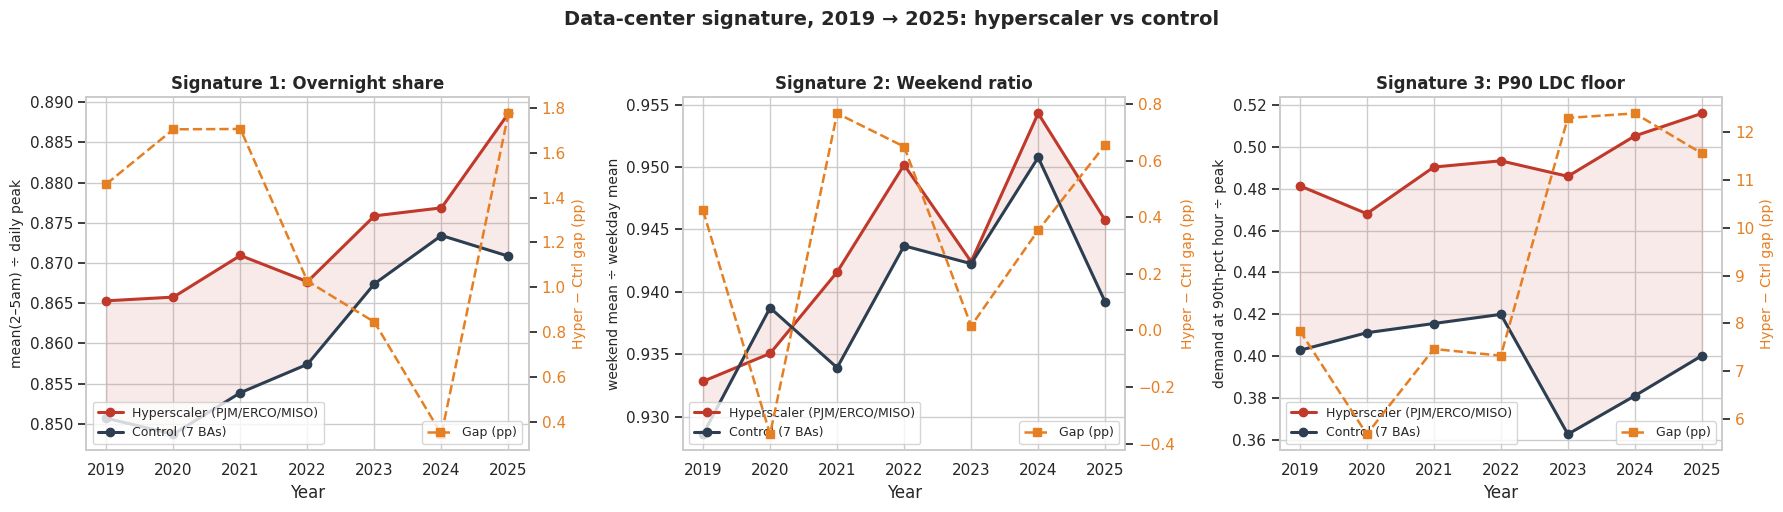

Saved data_center_signature_trend.png


In [5]:
group_means = panel.groupby(['year', 'group'])[['overnight_share', 'weekend_ratio', 'ldc_floor_p90']].mean().unstack('group')
gap = (group_means.xs('hyper', level='group', axis=1) - group_means.xs('ctrl', level='group', axis=1))

metrics = [
    ('overnight_share', 'Signature 1: Overnight share', 'mean(2–5am) ÷ daily peak'),
    ('weekend_ratio',   'Signature 2: Weekend ratio',   'weekend mean ÷ weekday mean'),
    ('ldc_floor_p90',   'Signature 3: P90 LDC floor',   'demand at 90th-pct hour ÷ peak'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (m, title, ylabel) in zip(axes, metrics):
    h = group_means[(m, 'hyper')]
    c = group_means[(m, 'ctrl')]
    g = gap[m]
    ax.plot(h.index, h.values, color=HYPER_COLOR, marker='o', lw=2.2, label='Hyperscaler (PJM/ERCO/MISO)')
    ax.plot(c.index, c.values, color=CTRL_COLOR,  marker='o', lw=2.2, label='Control (7 BAs)')
    ax.fill_between(h.index, c.values, h.values, color=HYPER_COLOR, alpha=0.10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel(ylabel, fontsize=10)
    ax.legend(loc='lower left', fontsize=9, frameon=True)

    ax2 = ax.twinx()
    ax2.plot(g.index, g.values * 100, color=GAP_COLOR, marker='s', linestyle='--', lw=1.8, label='Gap (pp)')
    ax2.set_ylabel('Hyper − Ctrl gap (pp)', color=GAP_COLOR, fontsize=10)
    ax2.tick_params(axis='y', labelcolor=GAP_COLOR)
    ax2.grid(False)
    ax2.legend(loc='lower right', fontsize=9, frameon=True)

fig.suptitle('Data-center signature, 2019 → 2025: hyperscaler vs control', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
out_png = PROCESSED / 'data_center_signature_trend.png'
plt.savefig(out_png, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved {out_png.name}')

## Per-BA trajectories — which grids flattened most?

Small multiples by BA. The hyperscaler thesis predicts PJM, ERCO, and MISO drift upward on overnight share and P90 floor; control BAs stay roughly flat (or move for unrelated reasons — CAISO, for example, is reshaping due to solar penetration, not data centers).

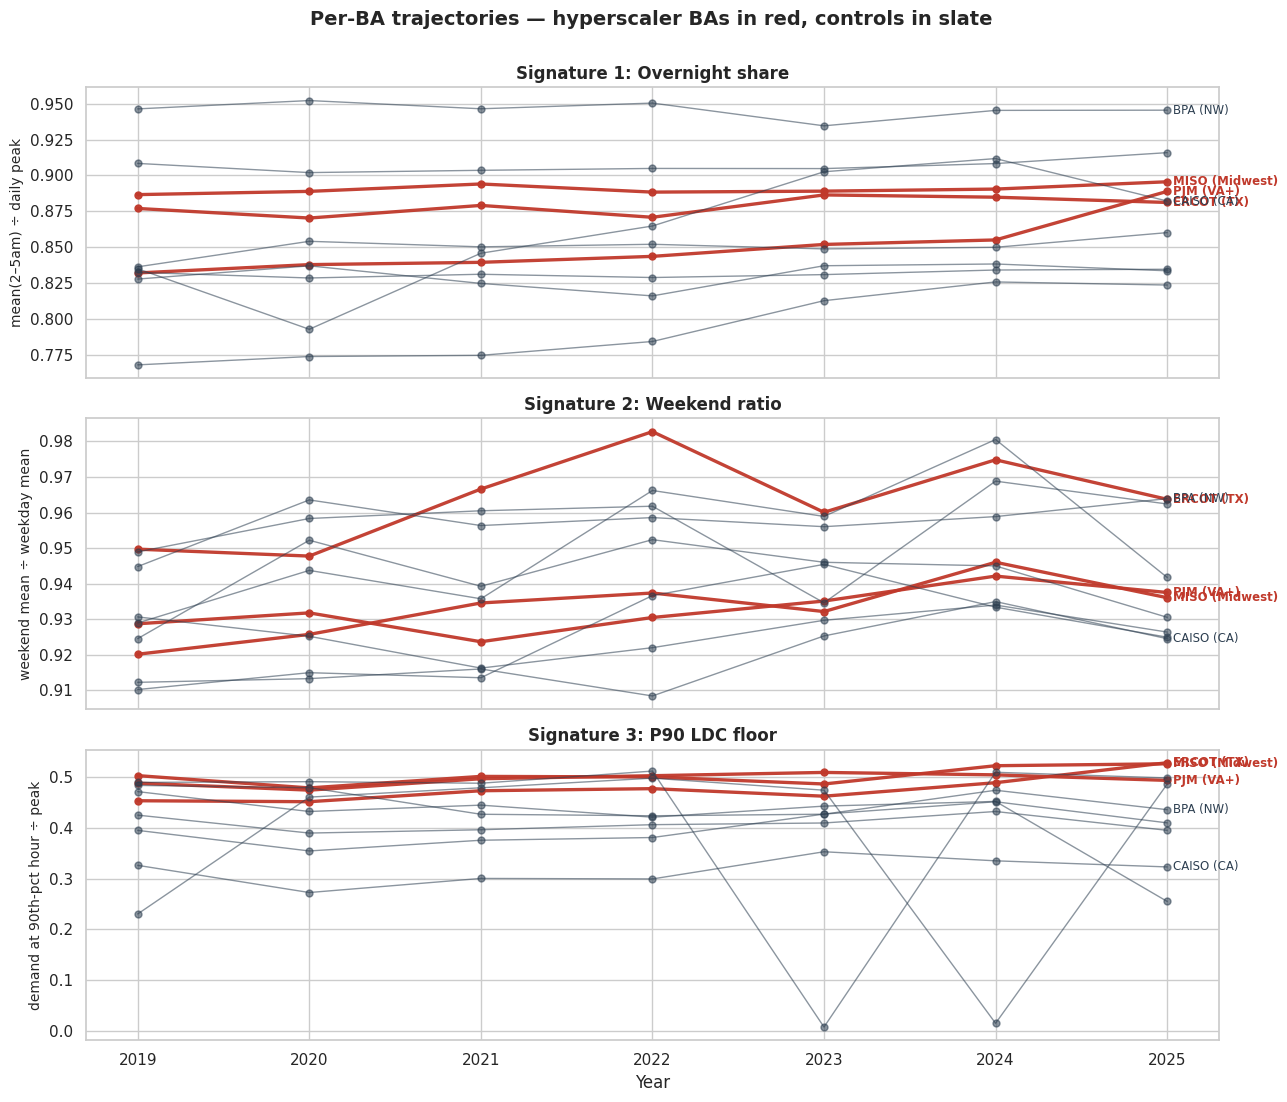

Saved data_center_signature_trend_per_ba.png


In [6]:
fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)
for ax, (m, title, ylabel) in zip(axes, metrics):
    for ba in BA_ORDER:
        sub = panel[panel['respondent'] == ba].sort_values('year')
        color = HYPER_COLOR if ba in HYPERSCALER else CTRL_COLOR
        lw = 2.4 if ba in HYPERSCALER else 1.0
        alpha = 0.95 if ba in HYPERSCALER else 0.55
        ax.plot(sub['year'], sub[m], color=color, lw=lw, alpha=alpha, marker='o', markersize=5)
        if ba in HYPERSCALER or ba in ['CISO', 'BPAT']:
            ax.annotate(BA_LABELS[ba], xy=(sub['year'].iloc[-1], sub[m].iloc[-1]),
                        xytext=(4, 0), textcoords='offset points', fontsize=8.5,
                        color=color, fontweight='bold' if ba in HYPERSCALER else 'normal',
                        va='center')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=10)
axes[-1].set_xlabel('Year')
fig.suptitle('Per-BA trajectories — hyperscaler BAs in red, controls in slate',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
out_png2 = PROCESSED / 'data_center_signature_trend_per_ba.png'
plt.savefig(out_png2, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved {out_png2.name}')

## Summary table

Year × signal × hyper × ctrl × gap, all in one place. This is the table that goes into the essay or its appendix.

In [7]:
summary = pd.concat({
    'hyper': group_means.xs('hyper', level='group', axis=1),
    'ctrl':  group_means.xs('ctrl',  level='group', axis=1),
    'gap':   gap,
}, axis=1).round(4)
summary.index.name = 'year'
print(summary.to_string())

out_csv = PROCESSED / 'data_center_signature_trend.csv'
summary.to_csv(out_csv)
print(f'\nSaved {out_csv.name}')

               hyper                                        ctrl                                         gap                            
     overnight_share weekend_ratio ldc_floor_p90 overnight_share weekend_ratio ldc_floor_p90 overnight_share weekend_ratio ldc_floor_p90
year                                                                                                                                    
2019          0.8653        0.9328        0.4813          0.8507        0.9286        0.4029          0.0146        0.0042        0.0785
2020          0.8657        0.9351        0.4681          0.8487        0.9387        0.4113          0.0170       -0.0037        0.0568
2021          0.8709        0.9416        0.4903          0.8539        0.9339        0.4157          0.0171        0.0077        0.0746
2022          0.8677        0.9502        0.4933          0.8574        0.9437        0.4200          0.0103        0.0065        0.0732
2023          0.8759        0.9424       

## Verdict

Read the orange dashed lines in the trend plots. If they slope upward, the data-center signature is strengthening over time and the Ed2 anchor has a real time-axis story. A flat or downward orange line would be a counterintuitive finding worth its own essay — not a thesis-killer, but a thesis-rewriter.